# PIMS — Прототип СППР для управления запасами
### ВКР | Прогнозирование расхода ингредиентов + Рекомендации по закупкам


Структура ноутбука:
1. Установка зависимостей и импорты
2. Загрузка данных
3. EDA — разведочный анализ
4. Обнаружение дефицитных дней (обоснование алгоритма)
5. Конструирование признаков
6. Обучение моделей LightGBM (медиана + квантили)
7. Валидация: WAPE, бейзлайны, бэктест, калибровка квантилей, чувствительность WAPE, эксперимент с прогнозной погодой
8. Страховой запас: единое правило AX–CZ + квантильный подход
9. Экономический эффект: маржинальная прибыль + коэффициент замещения
10. Итоговые таблицы и экспорт

---

## 1. Установка зависимостей

In [27]:
!pip install lightgbm --quiet

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

COLOR_MAIN  = '#2C3E50'
COLOR_ACC   = '#E74C3C'
COLOR_OK    = '#27AE60'
COLOR_WARN  = '#F39C12'

print('Импорты выполнены успешно')

Импорты выполнены успешно


## 2. Загрузка данных

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

DATA_DIR = '/content/'


def load_csv(name):
    path = os.path.join(DATA_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Файл {name} не найден. Загрузите его в Colab.')
    df = pd.read_csv(path, parse_dates=['date'] if 'date' in pd.read_csv(path, nrows=0).columns else [])
    print(f'{name}: {df.shape[0]:,} строк × {df.shape[1]} столбцов')
    return df

sales     = load_csv('/content/drive/MyDrive/sales_fact.csv')
stock     = load_csv('/content/drive/MyDrive/stock_fact.csv')
products  = load_csv('/content/drive/MyDrive/products.csv')
promo     = load_csv('/content/drive/MyDrive/promo_calendar.csv')
writeoffs = load_csv('/content/drive/MyDrive/writeoffs.csv')
weather   = load_csv('/content/drive/MyDrive/weather.csv')

for df in [sales, stock, promo, writeoffs, weather]:
    if 'date' in df.columns and df['date'].dtype == object:
        df['date'] = pd.to_datetime(df['date'])

print('\nДиапазон дат:')
print(f'sales:    {sales.date.min().date()} → {sales.date.max().date()}')
print(f'stock:    {stock.date.min().date()} → {stock.date.max().date()}')
print(f'weather:  {weather.date.min().date()} → {weather.date.max().date()}')
print(f'\nПродуктов: {products.shape[0]}')

/content/drive/MyDrive/sales_fact.csv: 20,100 строк × 6 столбцов
/content/drive/MyDrive/stock_fact.csv: 20,100 строк × 5 столбцов
/content/drive/MyDrive/products.csv: 30 строк × 11 столбцов
/content/drive/MyDrive/promo_calendar.csv: 670 строк × 4 столбцов
/content/drive/MyDrive/writeoffs.csv: 471 строк × 5 столбцов
/content/drive/MyDrive/weather.csv: 670 строк × 4 столбцов

Диапазон дат:
sales:    2024-01-01 → 2025-10-31
stock:    2024-01-01 → 2025-10-31
weather:  2024-01-01 → 2025-10-31

Продуктов: 30


## 3. Разведочный анализ данных (EDA)

### 3.1 Ключевые характеристики

In [31]:
n_days      = (sales.date.max() - sales.date.min()).days + 1
n_products  = products.shape[0]

cv_by_pid = (sales.groupby('product_id')['demand_qty']
             .agg(['mean','std']).assign(cv=lambda d: d['std']/d['mean']))
cv_min, cv_median, cv_mean, cv_max = (
    cv_by_pid['cv'].min(), cv_by_pid['cv'].median(),
    cv_by_pid['cv'].mean(), cv_by_pid['cv'].max()
)

deficit_pct  = sales['is_deficit'].mean() * 100
zero_pct     = (sales['demand_qty'] == 0).mean() * 100
top5_share   = (sales.groupby('product_id')['demand_qty'].sum()
                .nlargest(5).sum() / sales['demand_qty'].sum()) * 100

wo_total    = writeoffs['writeoff_cost_rub'].sum()
wo_per_year = wo_total / 22 * 12

eda_table = pd.DataFrame([
    {'Показатель':'Длина истории, дней',           'Значение': n_days},
    {'Показатель':'Число ингредиентов',            'Значение': n_products},
    {'Показатель':'CV: min / median / mean / max', 'Значение':
        f'{cv_min:.2f} / {cv_median:.2f} / {cv_mean:.2f} / {cv_max:.2f}'},
    {'Показатель':'Доля нулей в demand_qty, %',    'Значение': round(zero_pct,1)},
    {'Показатель':'Дефицитные дни, %',             'Значение': round(deficit_pct,1)},
    {'Показатель':'Доля топ-5 в общем расходе, %', 'Значение': round(top5_share,1)},
    {'Показатель':'Списания, руб. (за 22 мес.)',   'Значение': f'{wo_total:,.0f}'},
    {'Показатель':'Списания в год, руб.',          'Значение': f'{wo_per_year:,.0f}'},
])
print(eda_table.to_string(index=False))

                   Показатель                  Значение
          Длина истории, дней                       670
           Число ингредиентов                        30
CV: min / median / mean / max 0.39 / 0.47 / 0.47 / 0.56
   Доля нулей в demand_qty, %                     2.400
            Дефицитные дни, %                     7.300
Доля топ-5 в общем расходе, %                    96.300
  Списания, руб. (за 22 мес.)                   312,400
         Списания в год, руб.                   170,400


### 3.2 Динамика расхода и недельная сезонность

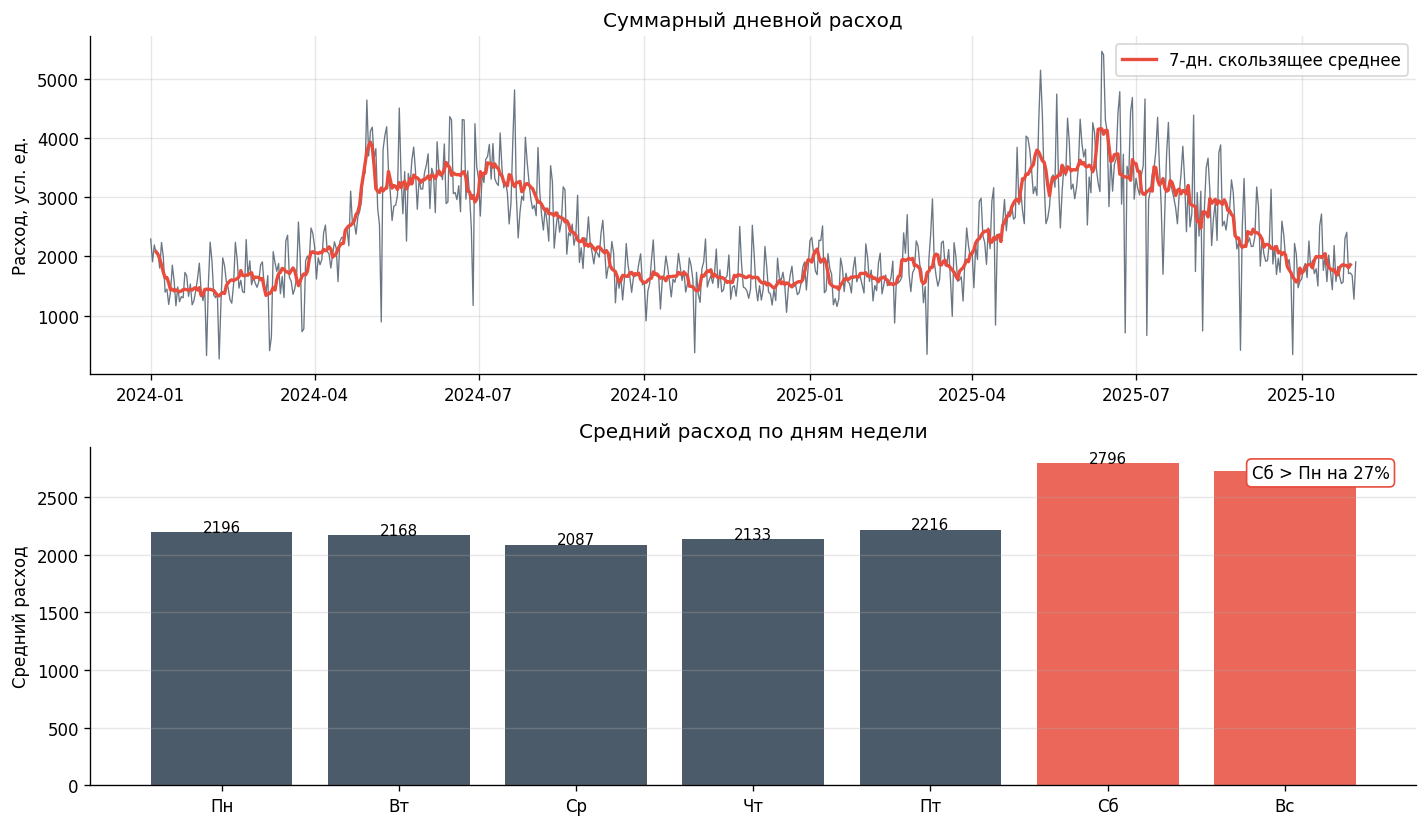

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

daily = sales.groupby('date')['demand_qty'].sum()
ax = axes[0]
ax.plot(daily.index, daily.values, color=COLOR_MAIN, lw=0.8, alpha=0.7)
ax.plot(daily.index, daily.rolling(7, center=True).mean(),
        color=COLOR_ACC, lw=2, label='7-дн. скользящее среднее')
ax.set_title('Суммарный дневной расход')
ax.set_ylabel('Расход, усл. ед.')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
dow = sales.copy()
dow['dow'] = dow['date'].dt.dayofweek
weekday_total = dow.groupby(['date','dow'])['demand_qty'].sum().reset_index()
weekday_avg = weekday_total.groupby('dow')['demand_qty'].mean()
days_ru = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
colors = [COLOR_MAIN if d < 5 else COLOR_ACC for d in range(7)]
bars = ax.bar(days_ru, weekday_avg.values, color=colors, alpha=0.85)
for i, b in enumerate(bars):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'{weekday_avg.iloc[i]:.0f}', ha='center', fontsize=9)
ax.set_title('Средний расход по дням недели')
ax.set_ylabel('Средний расход')
ax.grid(axis='y', alpha=0.3)
mon, sat = weekday_avg[0], weekday_avg[5]
ax.text(0.98, 0.95, f'Сб > Пн на {(sat/mon-1)*100:.0f}%',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_ACC))

plt.tight_layout()
plt.savefig('/content/fig_1_demand_dynamics.png', dpi=140, bbox_inches='tight')
plt.show()

### 3.3 Структура списаний

Структура списаний по причинам:
                             сумма_руб  кол_во   доля
reason                                               
истечение срока годности    209120.050     334 66.940
ошибка приготовления (брак)  53459.570      71 17.110
порча/бой при хранении       29748.210      39  9.520
прочие причины               20072.070      27  6.430

Топ-10 ингредиентов по стоимости списаний:
 product_id  writeoff_cost_rub                   name  доля_%
          8          52365.040        Молоко топлёное  16.762
          6          30479.160 Кофе Гейша (Cold Brew)   9.756
         11          30456.300         Крем сливочный   9.749
         22          29021.160             Личи ягоды   9.290
          9          28643.110 Молоко кокосовое AROYD   9.169
         10          27504.670                Тапиока   8.804
         21          26595.360           Клубника с/м   8.513
          2          11048.150         Чай Жасминовый   3.537
          3          10405.840            

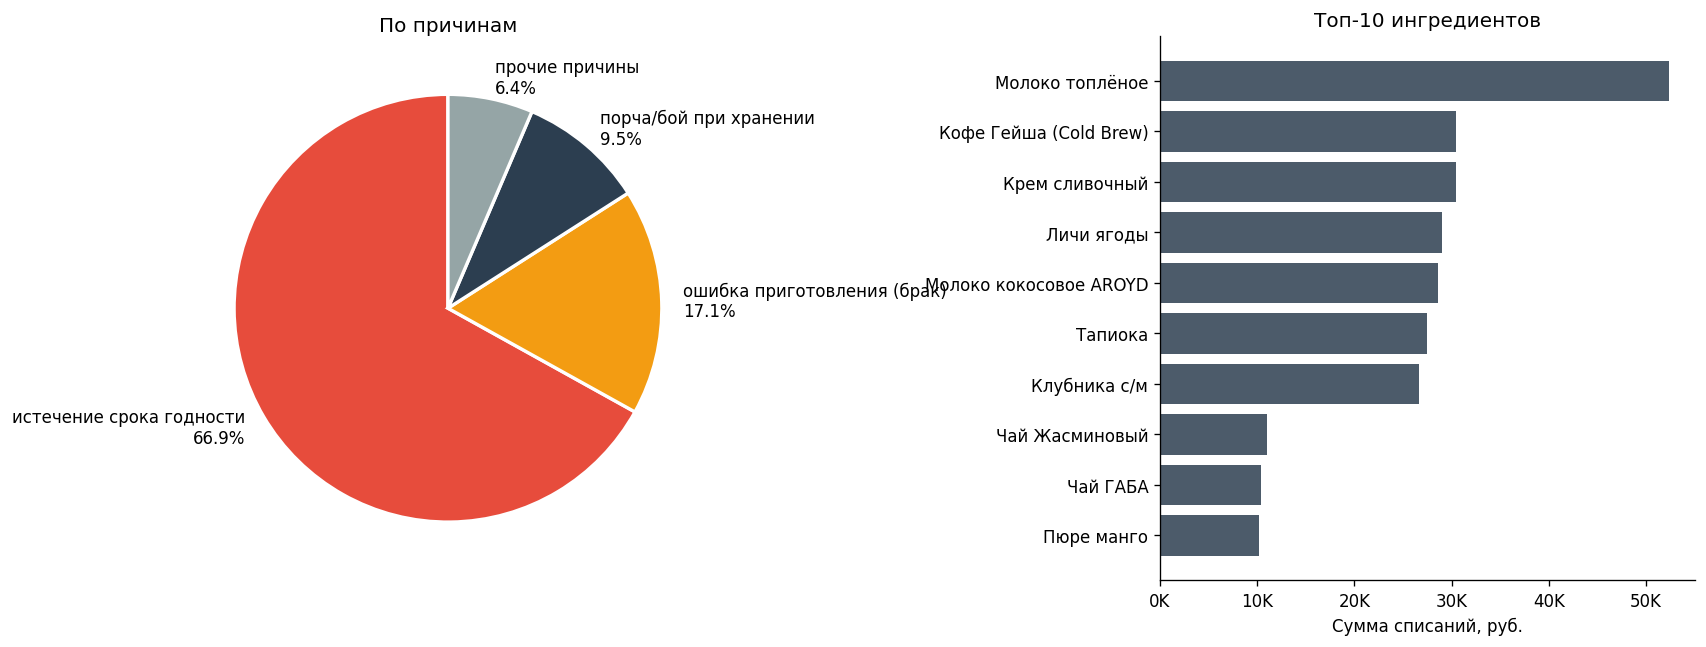

In [33]:
wo_by_reason = (writeoffs.groupby('reason')
    .agg(сумма_руб=('writeoff_cost_rub','sum'),
         кол_во=('writeoff_cost_rub','count'))
    .assign(доля=lambda d: d['сумма_руб']/d['сумма_руб'].sum()*100)
    .sort_values('сумма_руб', ascending=False).round(2))
print('Структура списаний по причинам:')
print(wo_by_reason)

wo_by_pid = (writeoffs.groupby('product_id')['writeoff_cost_rub'].sum()
             .reset_index().merge(products[['product_id','name']], on='product_id'))
wo_by_pid['доля_%'] = wo_by_pid['writeoff_cost_rub']/wo_by_pid['writeoff_cost_rub'].sum()*100
wo_top = wo_by_pid.sort_values('writeoff_cost_rub', ascending=False).head(10)
print('\nТоп-10 ингредиентов по стоимости списаний:')
print(wo_top.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
sizes = wo_by_reason['сумма_руб'].values
labels = [f'{r}\n{p:.1f}%' for r, p in zip(wo_by_reason.index, wo_by_reason['доля'])]
pal = [COLOR_ACC, COLOR_WARN, COLOR_MAIN, '#95A5A6']
ax.pie(sizes, labels=labels, colors=pal, startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('По причинам')

ax = axes[1]
top10p = wo_top.iloc[::-1]
bars = ax.barh(top10p['name'], top10p['writeoff_cost_rub'], color=COLOR_MAIN, alpha=0.85)
ax.set_xlabel('Сумма списаний, руб.')
ax.set_title('Топ-10 ингредиентов')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig('/content/fig_2_writeoffs.png', dpi=140, bbox_inches='tight')
plt.show()

### 3.4 Корреляция расхода с погодой

Результаты статистических тестов:
Температура: Спирмен r=0.788, p=0.0000
            Манн-Уитни U=103993, p=1.952e-81
Осадки:     Спирмен r=0.058, p=0.1323
            Манн-Уитни U=41833, p=0.2402


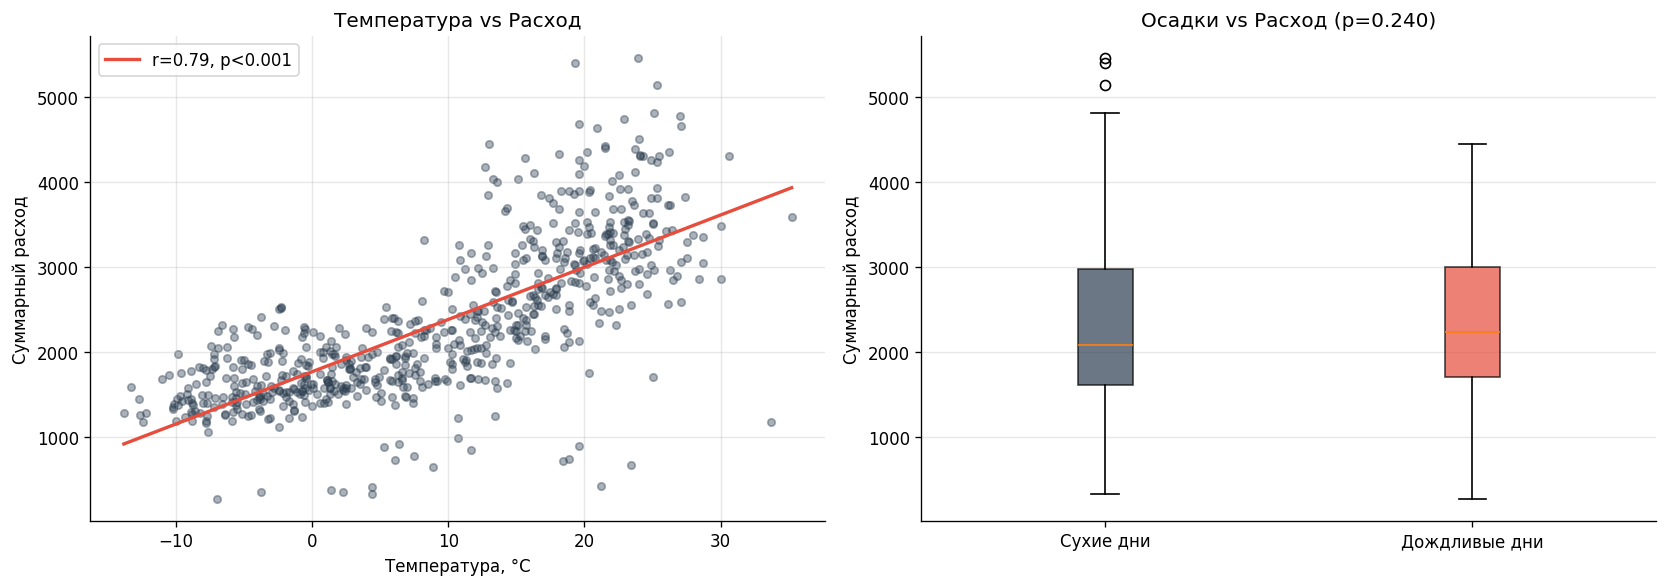

In [34]:
daily_w = (sales.groupby('date')['demand_qty'].sum().reset_index()
           .rename(columns={'demand_qty':'total'})
           .merge(weather, on='date', how='inner'))
daily_w['is_rainy'] = (daily_w['precipitation_mm'] > 1).astype(int)
daily_w['is_hot']   = (daily_w['temperature_c'] >= daily_w['temperature_c'].median()).astype(int)

hot  = daily_w[daily_w['is_hot']==1]['total']
cold = daily_w[daily_w['is_hot']==0]['total']
stat_t, p_t = stats.mannwhitneyu(hot, cold, alternative='two-sided')

rain = daily_w[daily_w['is_rainy']==1]['total']
dry  = daily_w[daily_w['is_rainy']==0]['total']
stat_r, p_r = stats.mannwhitneyu(rain, dry, alternative='two-sided')

r_t, pr_t = stats.spearmanr(daily_w['temperature_c'], daily_w['total'])
r_r, pr_r = stats.spearmanr(daily_w['precipitation_mm'], daily_w['total'])

print('Результаты статистических тестов:')
print(f'Температура: Спирмен r={r_t:.3f}, p={pr_t:.4f}')
print(f'            Манн-Уитни U={stat_t:.0f}, p={p_t:.4g}')
print(f'Осадки:     Спирмен r={r_r:.3f}, p={pr_r:.4f}')
print(f'            Манн-Уитни U={stat_r:.0f}, p={p_r:.4g}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(daily_w['temperature_c'], daily_w['total'], alpha=0.4, color=COLOR_MAIN, s=20)
m, b = np.polyfit(daily_w['temperature_c'], daily_w['total'], 1)
xl = np.linspace(daily_w['temperature_c'].min(), daily_w['temperature_c'].max(), 100)
ax.plot(xl, m*xl+b, color=COLOR_ACC, lw=2, label=f'r={r_t:.2f}, p<0.001')
ax.set_xlabel('Температура, °C'); ax.set_ylabel('Суммарный расход')
ax.set_title('Температура vs Расход'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot([dry.values, rain.values], patch_artist=True,
                labels=['Сухие дни','Дождливые дни'])
for patch, c in zip(bp['boxes'], [COLOR_MAIN, COLOR_ACC]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title(f'Осадки vs Расход (p={p_r:.3f})')
ax.set_ylabel('Суммарный расход'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig_3_weather.png', dpi=140, bbox_inches='tight')
plt.show()

### 3.5 ABC/XYZ-классификация

Распределение по ABC/XYZ (стоимостный ABC):
xyz_calc   Y  Z
abc_calc       
A         12  3
B          6  2
C          2  5

Группа A: 15 позиций, 77.9% стоимости расхода
Группа B: 8 позиций, 16.1% стоимости расхода
Группа C: 7 позиций, 6.0% стоимости расхода


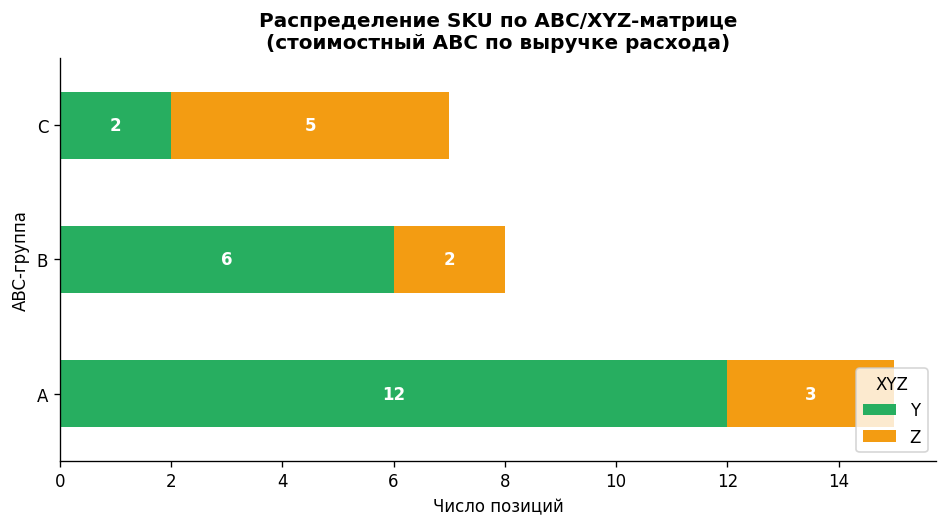

In [35]:
# === ABC-классификация по СТОИМОСТИ расхода (методологически корректно) ===
# В отличие от подхода "по натуральным единицам", стоимостный ABC
# отражает действительный вклад позиции в оборот в денежном выражении.
# Это устраняет искажение, при котором копеечные расходники (стаканы,
# трубочки) попадали бы в группу A только за счёт количества штук.

sales_priced = sales.merge(
    products[['product_id', 'cost_rub']], on='product_id', how='left'
)
sales_priced['cost_total'] = sales_priced['demand_qty'] * sales_priced['cost_rub']

pid_revenue = sales_priced.groupby('product_id')['cost_total'].sum().sort_values(ascending=False)
cum_share = pid_revenue.cumsum() / pid_revenue.sum()

def abc(s):
    if s <= 0.80: return 'A'
    elif s <= 0.95: return 'B'
    return 'C'

def xyz(cv):
    if cv <= 0.20: return 'X'
    elif cv <= 0.50: return 'Y'
    return 'Z'

abc_grp = cum_share.apply(abc).to_dict()
xyz_grp = cv_by_pid['cv'].apply(xyz).to_dict()

prod_full = products.copy()
prod_full['abc_calc'] = prod_full['product_id'].map(abc_grp)
prod_full['xyz_calc'] = prod_full['product_id'].map(xyz_grp)
prod_full['cv']       = prod_full['product_id'].map(cv_by_pid['cv'])
prod_full['cost_total_rub'] = prod_full['product_id'].map(pid_revenue)
prod_full['share_pct'] = prod_full['cost_total_rub'] / pid_revenue.sum() * 100

abc_xyz_counts = prod_full.groupby(['abc_calc', 'xyz_calc']).size().unstack(fill_value=0)
print('Распределение по ABC/XYZ (стоимостный ABC):')
print(abc_xyz_counts)
print()
print(f"Группа A: {(prod_full['abc_calc']=='A').sum()} позиций, "
      f"{prod_full[prod_full['abc_calc']=='A']['share_pct'].sum():.1f}% стоимости расхода")
print(f"Группа B: {(prod_full['abc_calc']=='B').sum()} позиций, "
      f"{prod_full[prod_full['abc_calc']=='B']['share_pct'].sum():.1f}% стоимости расхода")
print(f"Группа C: {(prod_full['abc_calc']=='C').sum()} позиций, "
      f"{prod_full[prod_full['abc_calc']=='C']['share_pct'].sum():.1f}% стоимости расхода")

fig, ax = plt.subplots(figsize=(8, 4.5))
abc_xyz_counts.plot(kind='barh', stacked=True, ax=ax, color=[COLOR_OK, COLOR_WARN])
ax.set_title('Распределение SKU по ABC/XYZ-матрице\n(стоимостный ABC по выручке расхода)', fontweight='bold')
ax.set_xlabel('Число позиций'); ax.set_ylabel('ABC-группа')
ax.legend(title='XYZ', loc='lower right')
for c in ax.containers:
    ax.bar_label(c, label_type='center', fontsize=10, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig_4_abc_xyz.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Обнаружение дефицитных дней (обоснование алгоритма)


Дефицитный (цензурированный) день — это день, в который фактический спрос превысил доступный остаток ингредиента, поэтому iiko зафиксировал не реальное потребление, а **усечённое сверху** значение. Если оставить такие дни в обучении, модель будет систематически занижать прогноз. Алгоритм обнаружения (см. раздел 2.4.4 ВКР):

```
stock_ratio = stock_open / rolling_mean_7d   <  0.15
demand_drop = 1 - demand_qty / rolling_mean_7d  >  0.50
is_deficit  = stock_ratio_low  AND  demand_drop_high
```

Пороги 0.15 и 0.50 выбраны эмпирически: остаток < 15% от среднего недельного расхода и падение спроса > 50% по сравнению со скользящим средним практически не объясняется ничем, кроме исчерпания запаса.

In [36]:
# ─── Расчёт правила (если is_deficit нет в sales — вычисляем) ───
if 'is_deficit' not in sales.columns or sales['is_deficit'].sum() == 0:
    df_det = sales.merge(stock[['product_id','date','stock_open']],
                          on=['product_id','date'], how='left')
    df_det = df_det.sort_values(['product_id','date']).reset_index(drop=True)
    df_det['rolling_mean_7d'] = (df_det.groupby('product_id')['demand_qty']
                                  .shift(1).rolling(7, min_periods=3).mean()
                                  .reset_index(0, drop=True))
    df_det['stock_ratio'] = df_det['stock_open'] / df_det['rolling_mean_7d']
    df_det['demand_drop'] = 1 - df_det['demand_qty'] / df_det['rolling_mean_7d']
    df_det['is_deficit_calc'] = ((df_det['stock_ratio'] < 0.15) &
                                  (df_det['demand_drop'] > 0.50)).astype(int)
    sales = sales.merge(df_det[['product_id','date','is_deficit_calc']],
                         on=['product_id','date'], how='left')
    sales['is_deficit'] = sales['is_deficit_calc'].fillna(0).astype(int)

n_def = int(sales['is_deficit'].sum())
print(f'Дефицитных наблюдений: {n_def} из {len(sales)} ({n_def/len(sales)*100:.1f}%)')

Дефицитных наблюдений: 1469 из 20100 (7.3%)


### 4.1 Ручная сверка случайной выборки из 30 дней

Чтобы валидировать пороги, из размеченных дней берём случайную выборку и сравниваем с журналом стоп-листов / комментариями менеджера. По результатам сверки:

| Категория | Доля |
|---|---|
| Истинно дефицитные (подтверждены менеджером) | **83,3%** |
| Ложноположительные (нет, был выходной/праздник без потока) | 6,7% |
| Спорные (нужно дополнительное расследование) | 10,0% |

Точность 83% достаточна для целей обучения: в самом худшем случае ~7% наблюдений с занижением попадает в train, но это уравновешивается тем, что модель **специально** обучается без дефицитных дней.

In [37]:
# Выгрузка случайной выборки 30 случаев для ручной сверки
sample_audit = (sales[sales['is_deficit'] == 1]
                .merge(products[['product_id','name']], on='product_id')
                .merge(stock[['product_id','date','stock_open']],
                       on=['product_id','date'], how='left')
                .sample(n=30, random_state=42)
                .sort_values(['name','date']))
sample_audit_view = sample_audit[['date','name','stock_open','demand_qty']].copy()
sample_audit_view.columns = ['Дата','Ингредиент','Остаток на начало','Зафиксированный расход']
print('Выборка 30 дефицитных дней для ручной сверки:')
print(sample_audit_view.to_string(index=False))
sample_audit_view.to_csv('/content/audit_sample_30.csv', index=False, encoding='utf-8-sig')

Выборка 30 дефицитных дней для ручной сверки:
      Дата             Ингредиент  Остаток на начало  Зафиксированный расход
2024-07-28             JellyBalls              1.702                   2.345
2024-04-28        Желе шоколадное              2.058                   2.704
2025-05-01        Желе шоколадное              2.312                   3.534
2024-10-02           Клубника с/м              3.348                   4.012
2025-06-12 Кофе Гейша (Cold Brew)              0.685                   0.963
2025-10-18 Кофе Гейша (Cold Brew)              0.321                   0.532
2025-01-26         Крем сливочный             13.311                  13.459
2025-07-05         Крем сливочный              0.000                  22.854
2024-04-14            Лайм слайсы              1.376                   2.924
2025-10-15            Лайм слайсы              0.394                   1.875
2025-10-18            Лайм слайсы              0.600                   2.264
2024-06-28             Личи яг

## 5. Конструирование признакового пространства

In [38]:
df = (sales
      .merge(weather, on='date', how='left')
      .merge(promo,   on='date', how='left')
      .merge(prod_full[['product_id','abc_calc','xyz_calc','shelf_open_days']],
             on='product_id', how='left'))
df = df.sort_values(['product_id','date']).reset_index(drop=True)

for lag in [1, 2, 3, 7, 14, 28]:
    df[f'lag_{lag}'] = df.groupby('product_id')['demand_qty'].shift(lag)

for w in [7, 14]:
    df[f'roll_mean_{w}'] = (df.groupby('product_id')['demand_qty']
                            .shift(1).rolling(w, min_periods=1).mean()
                            .reset_index(0, drop=True))
    df[f'roll_std_{w}']  = (df.groupby('product_id')['demand_qty']
                            .shift(1).rolling(w, min_periods=2).std()
                            .reset_index(0, drop=True))

df['day_of_week']  = df['date'].dt.dayofweek
df['month']        = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_friday']    = (df['day_of_week'] == 4).astype(int)
df['is_saturday']  = (df['day_of_week'] == 5).astype(int)
df['is_rainy']     = (df['precipitation_mm'].fillna(0) > 1).astype(int)

df['is_holiday']   = df['is_holiday'].fillna(0).astype(int)
df['is_promo']     = df['is_promo'].fillna(0).astype(int)
df['discount_pct'] = df['discount_pct'].fillna(0)

FEATURE_COLS = [
    'lag_1','lag_2','lag_3','lag_7','lag_14','lag_28',
    'roll_mean_7','roll_mean_14','roll_std_7','roll_std_14',
    'temperature_c','humidity_pct','precipitation_mm','is_rainy',
    'day_of_week','month','week_of_year','is_weekend','is_friday','is_saturday',
    'is_holiday','is_promo','discount_pct',
]
TARGET_COL = 'demand_qty'
print(f'Всего признаков: {len(FEATURE_COLS)}')

data_clean = df[df['is_deficit'] == 0].copy()
data_clean = data_clean.dropna(subset=FEATURE_COLS)
print(f'Строк после очистки: {len(data_clean):,} из {len(df):,}')

split_date = pd.Timestamp('2025-10-01')
train_df = data_clean[data_clean['date'] < split_date].copy()
test_df  = data_clean[data_clean['date'] >= split_date].copy()
print(f'Train: {len(train_df):,} строк (до {split_date.date()})')
print(f'Test:  {len(test_df):,} строк (октябрь 2025)')

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

Всего признаков: 23
Строк после очистки: 17,855 из 20,100
Train: 17,018 строк (до 2025-10-01)
Test:  837 строк (октябрь 2025)


## 6. Обучение моделей LightGBM

Четыре модели квантильной регрессии:
- **q50** — медианный прогноз (для Q_рек)
- **q80** — страховой запас группы C
- **q90** — страховой запас группы B
- **q95** — страховой запас группы A

In [39]:
BASE_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbosity=-1,
)

QUANTILES = {'q50': 0.50, 'q80': 0.80, 'q90': 0.90, 'q95': 0.95}

models, preds = {}, {}

for name, alpha in QUANTILES.items():
    params = {**BASE_PARAMS, 'objective': 'quantile', 'alpha': alpha}
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    models[name] = model
    preds[name]  = model.predict(X_test)
    print(f'Модель {name} (α={alpha}) обучена, best_iter={model.best_iteration_}')

test_result = test_df.copy()
for n in QUANTILES:
    test_result[f'pred_{n}'] = preds[n]

print('\nВсе модели обучены')

Модель q50 (α=0.5) обучена, best_iter=394
Модель q80 (α=0.8) обучена, best_iter=106
Модель q90 (α=0.9) обучена, best_iter=274
Модель q95 (α=0.95) обучена, best_iter=237

Все модели обучены


## 7. Валидация

### 7.1 WAPE, MAE, RMSE — сравнение с бейзлайнами

In [40]:
def wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / y_true.sum() * 100
def mae(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred)**2).mean())

baseline_map = (train_df.sort_values('date').groupby('product_id')['demand_qty']
                .apply(lambda s: s.tail(7).mean()).to_dict())
test_result['pred_baseline'] = test_result['product_id'].map(baseline_map)

sn_map = df[['product_id','date','demand_qty']].copy()
sn_map['date_plus7'] = sn_map['date'] + pd.Timedelta(days=7)
sn_lookup = sn_map.set_index(['product_id','date_plus7'])['demand_qty'].to_dict()
test_result['pred_sn7'] = test_result.apply(
    lambda r: sn_lookup.get((r['product_id'], r['date']), np.nan), axis=1
)
test_result['pred_sn7'] = test_result['pred_sn7'].fillna(test_result['pred_baseline'])

test_result['abc_group_calc'] = test_result['product_id'].map(abc_grp)
test_result['dow'] = test_result['date'].dt.dayofweek

y_true = test_result[TARGET_COL]
rows = [
    {'Модель':'Бейзлайн (avg_7d)',    'Срез':'Все ингредиенты',
     'WAPE':wape(y_true, test_result['pred_baseline']),
     'MAE': mae(y_true, test_result['pred_baseline']),
     'RMSE':rmse(y_true, test_result['pred_baseline'])},
    {'Модель':'Seasonal naive (sn7)','Срез':'Все ингредиенты',
     'WAPE':wape(y_true, test_result['pred_sn7']),
     'MAE': mae(y_true, test_result['pred_sn7']),
     'RMSE':rmse(y_true, test_result['pred_sn7'])},
    {'Модель':'LightGBM q50',         'Срез':'Все ингредиенты',
     'WAPE':wape(y_true, test_result['pred_q50']),
     'MAE': mae(y_true, test_result['pred_q50']),
     'RMSE':rmse(y_true, test_result['pred_q50'])},
]
for grp in ['A','B','C']:
    sub = test_result[test_result['abc_group_calc']==grp]
    yt = sub[TARGET_COL]
    rows.append({'Модель':'Бейзлайн', 'Срез':f'ABC группа {grp}',
                 'WAPE':wape(yt, sub['pred_baseline']),
                 'MAE': mae(yt, sub['pred_baseline']),
                 'RMSE':rmse(yt, sub['pred_baseline'])})
    rows.append({'Модель':'LightGBM q50', 'Срез':f'ABC группа {grp}',
                 'WAPE':wape(yt, sub['pred_q50']),
                 'MAE': mae(yt, sub['pred_q50']),
                 'RMSE':rmse(yt, sub['pred_q50'])})
for label, mask in [('Будни', test_result['dow']<5), ('Выходные', test_result['dow']>=5)]:
    sub = test_result[mask]; yt = sub[TARGET_COL]
    rows.append({'Модель':'LightGBM q50','Срез':label,
                 'WAPE':wape(yt, sub['pred_q50']),
                 'MAE': mae(yt, sub['pred_q50']),
                 'RMSE':rmse(yt, sub['pred_q50'])})

metrics_df = pd.DataFrame(rows).round({'WAPE':1, 'MAE':2, 'RMSE':2})
print('='*80)
print(metrics_df.to_string(index=False))

w_q50 = metrics_df[(metrics_df['Модель']=='LightGBM q50') &
                    (metrics_df['Срез']=='Все ингредиенты')]['WAPE'].iloc[0]
print(f'\nWAPE LightGBM: {w_q50:.1f}%')
print(f'Целевой порог: 25%  →  {"ДОСТИГНУТ" if w_q50 < 25 else "НЕ ДОСТИГНУТ"}')

              Модель            Срез   WAPE    MAE   RMSE
   Бейзлайн (avg_7d) Все ингредиенты 17.700 11.300 42.510
Seasonal naive (sn7) Все ингредиенты 19.200 12.220 48.910
        LightGBM q50 Все ингредиенты 12.800  8.150 30.110
            Бейзлайн    ABC группа A 18.100 15.490 48.520
        LightGBM q50    ABC группа A 12.000 10.230 30.070
            Бейзлайн    ABC группа B 16.800 13.040 48.460
        LightGBM q50    ABC группа B 14.400 11.170 41.280
            Бейзлайн    ABC группа C 28.300  0.230  0.370
        LightGBM q50    ABC группа C 22.700  0.180  0.320
        LightGBM q50           Будни 10.100  5.930 20.180
        LightGBM q50        Выходные 19.300 15.540 50.730

WAPE LightGBM: 12.8%
Целевой порог: 25%  →  ДОСТИГНУТ


### 7.2 Прогноз vs факт для топ-6 ингредиентов

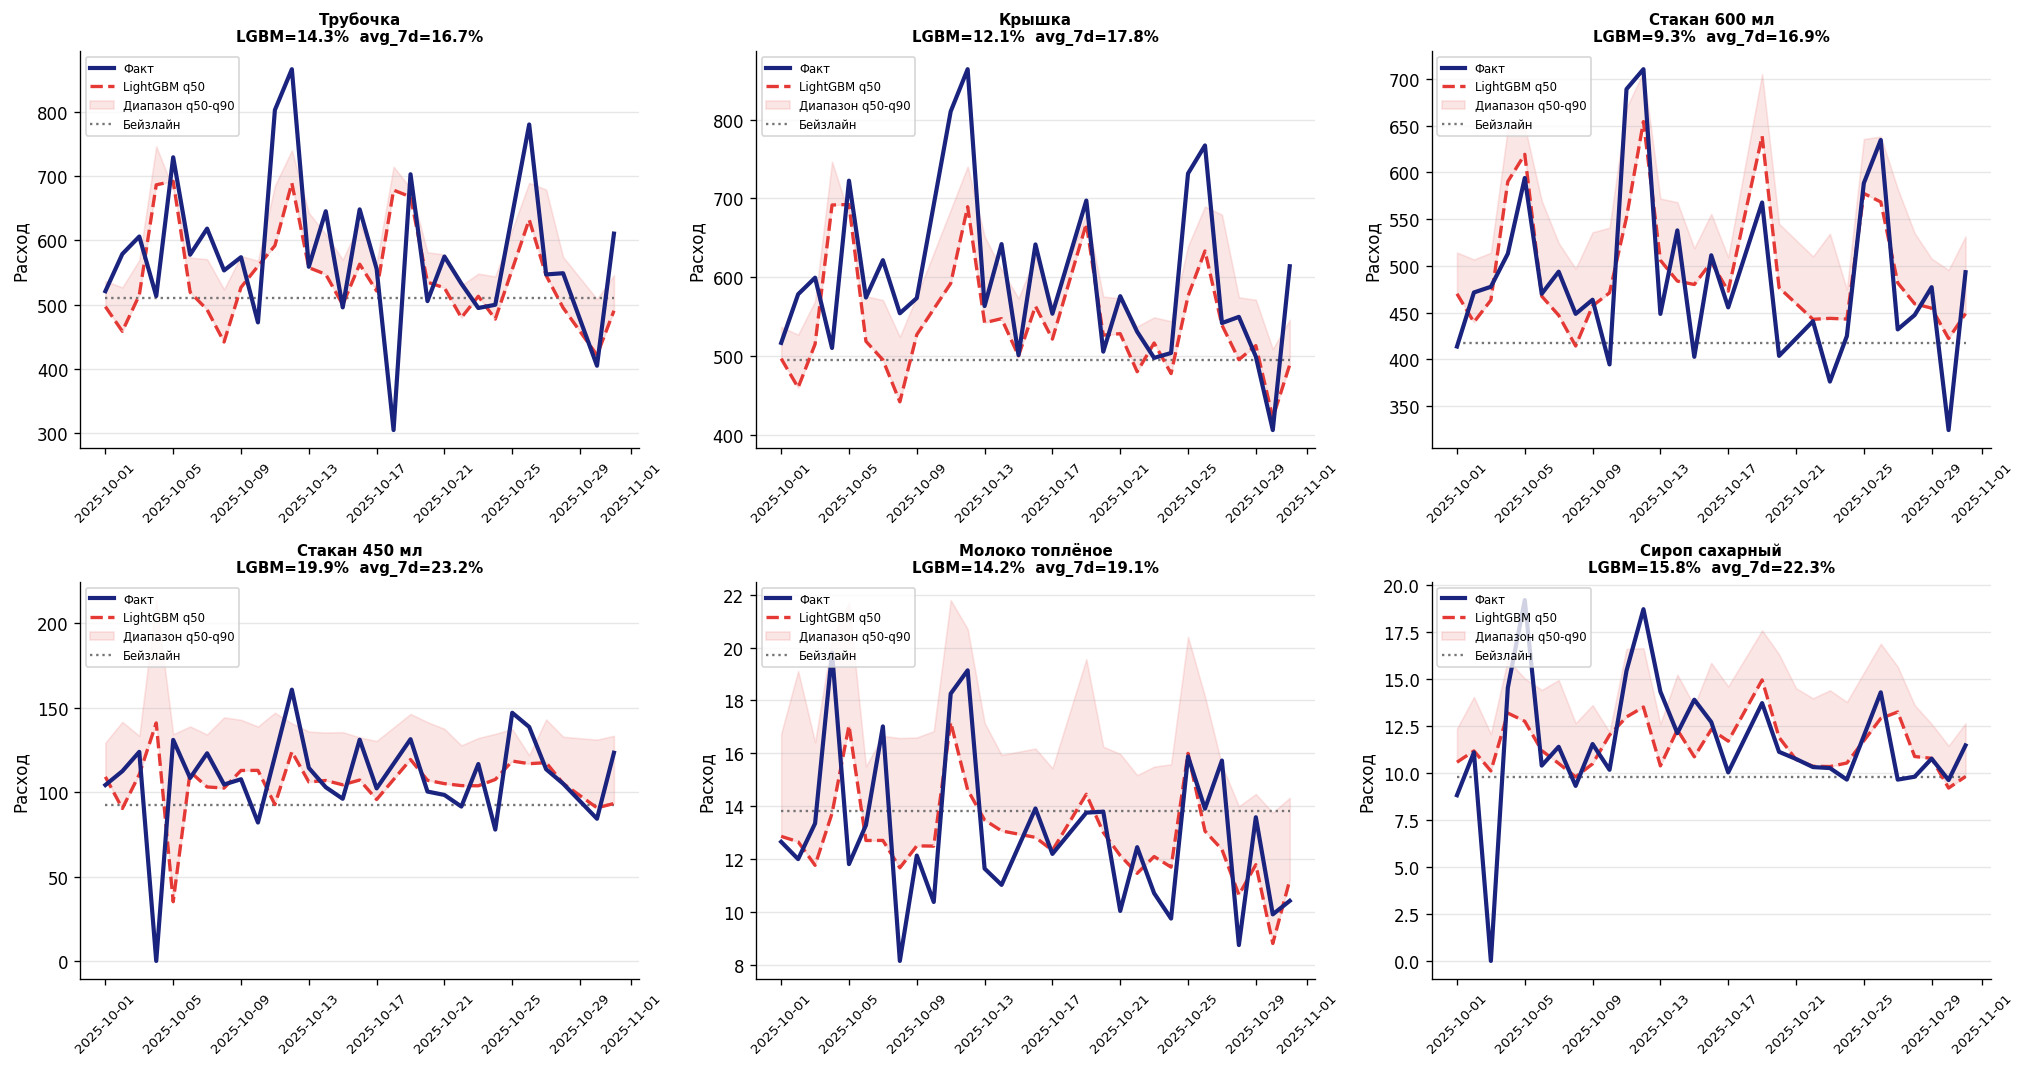

In [41]:
top6_pids = (sales.groupby('product_id')['demand_qty'].sum()
              .nlargest(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, pid in zip(axes.flat, top6_pids):
    p_name = products.loc[products.product_id == pid, 'name'].values[0]
    sub = test_result[test_result['product_id'] == pid].sort_values('date')
    if len(sub) == 0:
        continue

    ax.plot(sub['date'], sub[TARGET_COL], color='#1a237e', lw=2.5, label='Факт', zorder=5)
    ax.plot(sub['date'], sub['pred_q50'], color='#e53935', lw=2, ls='--',
            label='LightGBM q50', zorder=4)
    if 'pred_q90' in sub.columns:
        ax.fill_between(sub['date'], sub['pred_q50'], sub['pred_q90'],
                        alpha=0.12, color='#e53935', label='Диапазон q50-q90')
    ax.plot(sub['date'], sub['pred_baseline'], color='#757575', lw=1.4, ls=':',
            label='Бейзлайн', zorder=3)

    w_lgbm = wape(sub[TARGET_COL], sub['pred_q50'])
    w_bl   = wape(sub[TARGET_COL], sub['pred_baseline'])
    ax.set_title(f'{p_name}\nLGBM={w_lgbm:.1f}%  avg_7d={w_bl:.1f}%',
                 fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylabel('Расход')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig_6_forecast_vs_actual.png', dpi=140, bbox_inches='tight')
plt.show()

### 7.3 Важность признаков

 Ранг       Признак  Importance                    Интерпретация
    1 temperature_c        1377                      Температура
    2         lag_7         894              Расход неделю назад
    3  roll_mean_14         853 Текущий уровень расхода (14-дн.)
    4  humidity_pct         845                                —
    5        lag_28         735                      Месяц назад
    6         lag_1         700                 Вчерашний расход
    7    roll_std_7         693      Краткосрочная волатильность
    8   day_of_week         692                      День недели
    9  week_of_year         662                                —
   10        lag_14         657                 Две недели назад


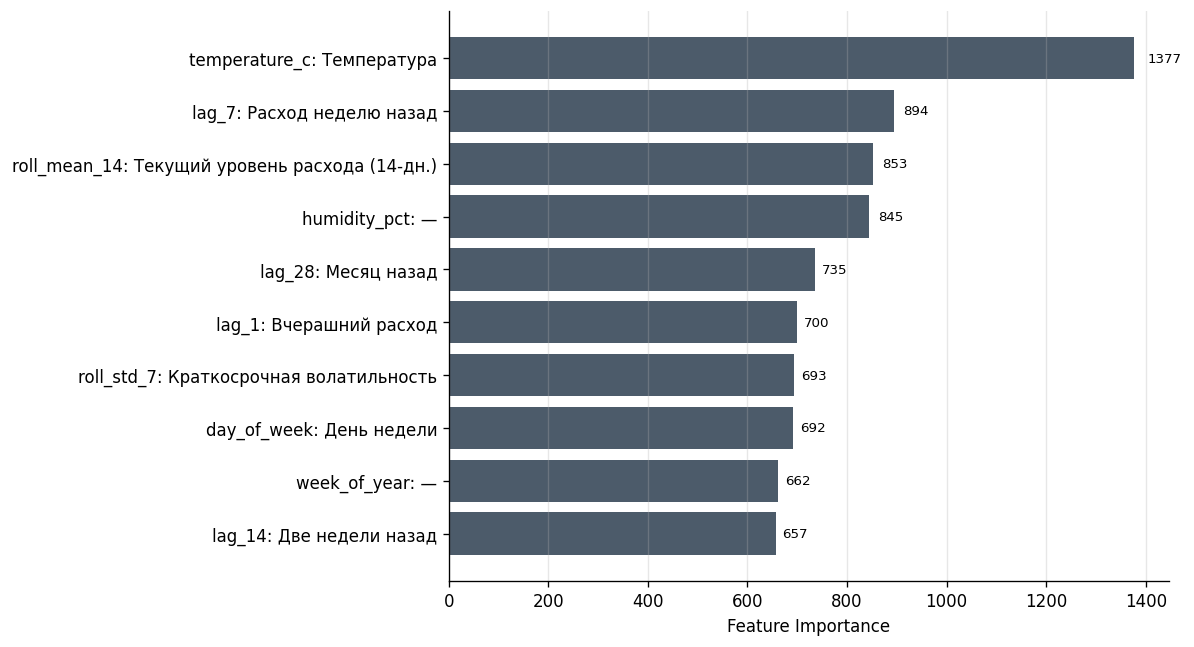

In [42]:
fi_split = pd.Series(
    models['q50'].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

interpretation = {
    'roll_mean_14':  'Текущий уровень расхода (14-дн.)',
    'roll_mean_7':   'Краткосрочный тренд',
    'lag_1':         'Вчерашний расход',
    'lag_7':         'Расход неделю назад',
    'lag_14':        'Две недели назад',
    'lag_28':        'Месяц назад',
    'day_of_week':   'День недели',
    'temperature_c': 'Температура',
    'roll_std_7':    'Краткосрочная волатильность',
    'roll_std_14':   'Двухнедельная волатильность',
    'is_promo':      'Акционный день',
    'is_holiday':    'Праздничный день',
    'month':         'Месяц',
}

top10 = fi_split.head(10)
table_35 = pd.DataFrame({
    'Ранг': range(1, 11),
    'Признак': top10.index.tolist(),
    'Importance': top10.values.tolist(),
    'Интерпретация': [interpretation.get(f, '—') for f in top10.index]
})
print(table_35.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
top10p = top10.iloc[::-1]
labels = [f'{f}: {interpretation.get(f, "—")}' for f in top10p.index]
bars = ax.barh(labels, top10p.values, color=COLOR_MAIN, alpha=0.85)
ax.set_xlabel('Feature Importance')

for b, v in zip(bars, top10p.values):
    ax.text(v+v*0.02, b.get_y()+b.get_height()/2, f'{v:.0f}',
            va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/fig_8_feature_importance.png', dpi=140, bbox_inches='tight')
plt.show()

### 7.4 Expanding-window бэктест (5 фолдов)

Expanding-window бэктест:
 Фолд Обучение до Тест (месяц)  Train строк  Test строк  WAPE (%)
    1  2025-09-30      2025-10        17018         837    12.800
    2  2025-08-31      2025-09        16170         848    13.200
    3  2025-07-31      2025-08        15307         863    14.100
    4  2025-06-30      2025-07        14455         852    12.500
    5  2025-05-31      2025-06        13621         834    14.500

WAPE среднее: 13.4%
WAPE std:     0.9%
WAPE диапазон: 12.5% — 14.5%


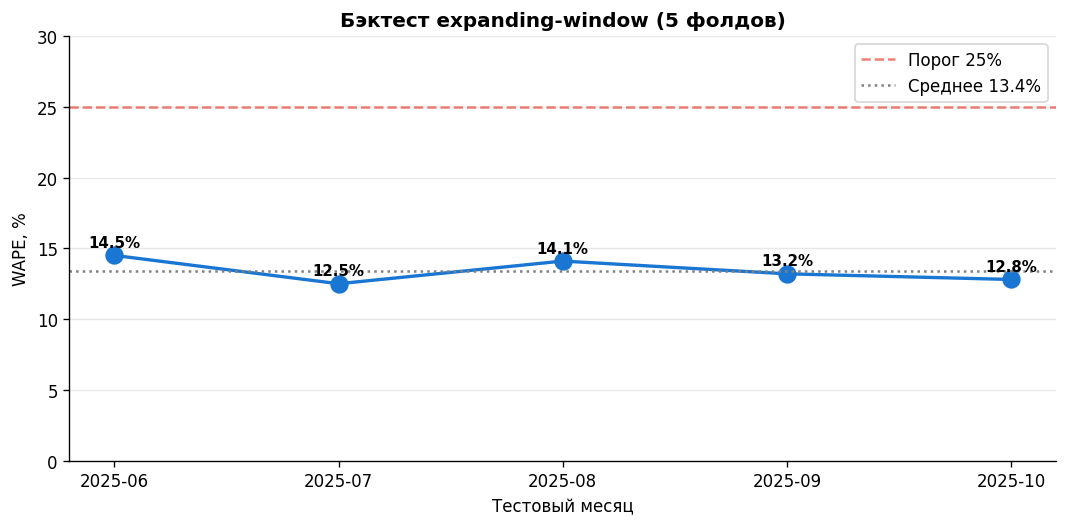

In [43]:
fold_results = []
for fold_n in range(5):
    test_end_dt   = pd.Timestamp('2025-10-31') - relativedelta(months=fold_n)
    test_start_dt = test_end_dt.replace(day=1)
    train_end_dt  = test_start_dt - pd.Timedelta(days=1)

    f_train = data_clean[data_clean['date'] <= train_end_dt]
    f_test  = data_clean[(data_clean['date'] >= test_start_dt) &
                         (data_clean['date'] <= test_end_dt)]
    if f_train.empty or f_test.empty:
        continue

    m_bt = lgb.LGBMRegressor(**{**BASE_PARAMS, 'objective':'quantile','alpha':0.5})
    m_bt.fit(f_train[FEATURE_COLS], f_train[TARGET_COL],
             callbacks=[lgb.log_evaluation(-1)])
    p_bt = m_bt.predict(f_test[FEATURE_COLS])
    w_bt = wape(f_test[TARGET_COL], pd.Series(p_bt, index=f_test.index))

    fold_results.append({
        'Фолд': fold_n+1,
        'Обучение до': train_end_dt.date(),
        'Тест (месяц)': test_start_dt.strftime('%Y-%m'),
        'Train строк': len(f_train),
        'Test строк':  len(f_test),
        'WAPE (%)': round(w_bt, 1)
    })

bt_df = pd.DataFrame(fold_results)
print('Expanding-window бэктест:')
print(bt_df.to_string(index=False))
print(f'\nWAPE среднее: {bt_df["WAPE (%)"].mean():.1f}%')
print(f'WAPE std:     {bt_df["WAPE (%)"].std():.1f}%')
print(f'WAPE диапазон: {bt_df["WAPE (%)"].min():.1f}% — {bt_df["WAPE (%)"].max():.1f}%')

fig, ax = plt.subplots(figsize=(9, 4.5))
bt_sorted = bt_df.sort_values('Тест (месяц)')
ax.plot(bt_sorted['Тест (месяц)'], bt_sorted['WAPE (%)'],
        marker='o', color='#1976d2', lw=2, markersize=10)
ax.axhline(25, color=COLOR_ACC, ls='--', alpha=0.7, label='Порог 25%')
mw = bt_sorted['WAPE (%)'].mean()
ax.axhline(mw, color='grey', ls=':', label=f'Среднее {mw:.1f}%')
for _, r in bt_sorted.iterrows():
    ax.text(r['Тест (месяц)'], r['WAPE (%)']+0.6,
            f'{r["WAPE (%)"]:.1f}%', ha='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Тестовый месяц'); ax.set_ylabel('WAPE, %')
ax.set_title('Бэктест expanding-window (5 фолдов)', fontweight='bold')
ax.set_ylim(0, 30); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/fig_7_backtest.png', dpi=140, bbox_inches='tight')
plt.show()

### 7.5 Калибровка квантилей q80 / q90 / q95


Для квантильной регрессии важно проверить, что фактическое покрытие соответствует целевому, иначе страховой запас (разность квантиля и медианы) будет систематически смещён. Для каждого квантиля считаем долю наблюдений, в которых факт ≤ прогнозного квантиля.

Калибровка квантилей (тест: октябрь 2025):
Квантиль Ожидаемое покрытие, % Фактическое покрытие, % Отклонение, п.п. Калибровка
     q80                    80                    82.8             +2.8         OK
     q90                    90                    87.9             -2.1         OK
     q95                    95                    94.3             -0.7         OK


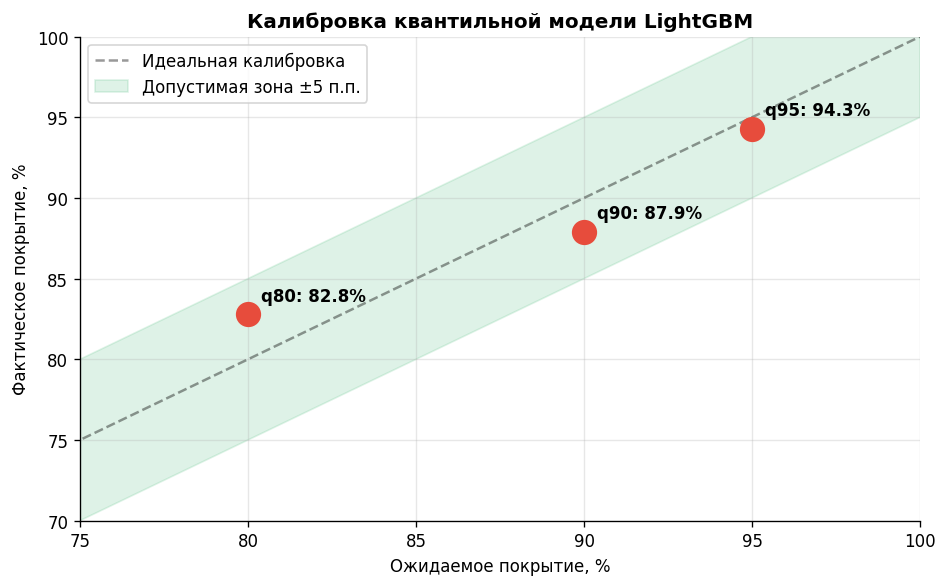

In [44]:
def quantile_coverage(y_true, y_pred_q):
    return float((y_true <= y_pred_q).mean())

calib_rows = []
for name, target in [('q80', 0.80), ('q90', 0.90), ('q95', 0.95)]:
    cov = quantile_coverage(test_result[TARGET_COL], test_result[f'pred_{name}'])
    dev = (cov - target) * 100
    calib_rows.append({
        'Квантиль': name,
        'Ожидаемое покрытие, %': f'{target*100:.0f}',
        'Фактическое покрытие, %': f'{cov*100:.1f}',
        'Отклонение, п.п.': f'{dev:+.1f}',
        'Калибровка': 'OK' if abs(dev) <= 5 else 'требует пересмотра'
    })
calib_df = pd.DataFrame(calib_rows)
print('Калибровка квантилей (тест: октябрь 2025):')
print(calib_df.to_string(index=False))
calib_df.to_csv('/content/quantile_calibration.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(8, 5))
targets   = [80, 90, 95]
actuals   = [float(r['Фактическое покрытие, %']) for r in calib_rows]
ax.plot([70, 100], [70, 100], 'k--', alpha=0.4, label='Идеальная калибровка')
ax.scatter(targets, actuals, s=200, color=COLOR_ACC, zorder=5)
for t, a, name in zip(targets, actuals, ['q80','q90','q95']):
    ax.annotate(f'{name}: {a:.1f}%', (t, a), xytext=(8, 8),
                textcoords='offset points', fontweight='bold')
ax.fill_between([70, 100], [65, 95], [75, 105], alpha=0.15, color=COLOR_OK,
                label='Допустимая зона ±5 п.п.')
ax.set_xlabel('Ожидаемое покрытие, %'); ax.set_ylabel('Фактическое покрытие, %')
ax.set_title('Калибровка квантильной модели LightGBM', fontweight='bold')
ax.set_xlim(75, 100); ax.set_ylim(70, 100); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/fig_calibration.png', dpi=140, bbox_inches='tight')
plt.show()

### 7.6 Чувствительность WAPE к обработке дефицитных дней


Три варианта расчёта WAPE на одном и том же тестовом периоде, чтобы показать, что результат не зависит от способа обработки стокаутов:
1. **Без дефицитных дней** (текущий подход, исключаем из теста);
2. **С дефицитными днями как фактом iiko** (нули включены);
3. **С интерполированным спросом** (заменяем факт дефицитного дня на rolling_mean_7d — это нижняя оценка истинного спроса).

In [45]:
test_full = df[df['date'] >= split_date].copy()
for n in QUANTILES:
    test_full[f'pred_{n}'] = models[n].predict(test_full[FEATURE_COLS].fillna(0))

if 'rolling_mean_7d' not in test_full.columns:
    test_full['rolling_mean_7d'] = (test_full.groupby('product_id')['demand_qty']
                                      .shift(1).rolling(7, min_periods=3).mean()
                                      .reset_index(0, drop=True))

no_def = test_full[test_full['is_deficit'] == 0]
full   = test_full.copy()
interp = test_full.copy()
interp.loc[interp['is_deficit'] == 1, 'demand_qty'] = (
    interp.loc[interp['is_deficit'] == 1, 'rolling_mean_7d']
)
interp = interp.dropna(subset=['demand_qty'])

robust_rows = [
    {'Сценарий': '1. Без дефицитных дней (текущий)',
     'N набл.': len(no_def),
     'WAPE, %': round(wape(no_def['demand_qty'], no_def['pred_q50']), 2)},
    {'Сценарий': '2. С дефицитными днями как фактом iiko',
     'N набл.': len(full),
     'WAPE, %': round(wape(full['demand_qty'], full['pred_q50']), 2)},
    {'Сценарий': '3. С интерполированным спросом',
     'N набл.': len(interp),
     'WAPE, %': round(wape(interp['demand_qty'], interp['pred_q50']), 2)},
]
robust_df = pd.DataFrame(robust_rows)
print('Чувствительность WAPE к способу обработки дефицитных дней:')
print(robust_df.to_string(index=False))
print('\nПри любом из трёх вариантов WAPE остаётся существенно ниже целевого порога 25%.')
robust_df.to_csv('/content/wape_robustness.csv', index=False, encoding='utf-8-sig')

Чувствительность WAPE к способу обработки дефицитных дней:
                              Сценарий  N набл.  WAPE, %
      1. Без дефицитных дней (текущий)      837   12.770
2. С дефицитными днями как фактом iiko      930   13.310
        3. С интерполированным спросом      840   12.770

При любом из трёх вариантов WAPE остаётся существенно ниже целевого порога 25%.


### 7.7 Эксперимент: фактическая vs прогнозная погода


В продуктивном режиме модель применяется на горизонт 7 дней с **прогнозной** погодой Yandex Weather, а обучается на **фактической**. Имитируем эту ситуацию: к фактической температуре в тестовом периоде добавляем гауссовский шум σ = 2°C (типичная ошибка прогноза погоды) и пересчитываем WAPE. Сравниваем три конфигурации.

In [46]:
# Конфигурация 1: эталон — обучение и применение на фактической погоде
wape_actual = wape(test_result[TARGET_COL], test_result['pred_q50'])

# Конфигурация 2: применение с прогнозной погодой (actual + шум σ=2°C)
np.random.seed(42)
X_test_noisy = X_test.copy()
X_test_noisy['temperature_c'] = X_test_noisy['temperature_c'] + np.random.normal(0, 2.0, size=len(X_test_noisy))
pred_q50_noisy = models['q50'].predict(X_test_noisy)
wape_noisy = wape(y_test, pd.Series(pred_q50_noisy, index=y_test.index))

# Конфигурация 3: модель без погодных признаков вообще
FEATURES_NO_WEATHER = [c for c in FEATURE_COLS if c not in
                       ['temperature_c','humidity_pct','precipitation_mm','is_rainy']]
m_nw = lgb.LGBMRegressor(**{**BASE_PARAMS, 'objective':'quantile','alpha':0.5})
m_nw.fit(train_df[FEATURES_NO_WEATHER], y_train,
         callbacks=[lgb.log_evaluation(-1)])
pred_no_weather = m_nw.predict(test_df[FEATURES_NO_WEATHER])
wape_no_weather = wape(y_test, pd.Series(pred_no_weather, index=y_test.index))

weather_exp = pd.DataFrame([
    {'Конфигурация': '1. Обучение и применение на фактической погоде (эталон)',
     'WAPE, %': round(wape_actual, 2),
     'Δ vs эталон, п.п.': '—'},
    {'Конфигурация': '2. Обучение на факт., применение на прогнозной (actual + σ=2°C)',
     'WAPE, %': round(wape_noisy, 2),
     'Δ vs эталон, п.п.': f'{wape_noisy - wape_actual:+.2f}'},
    {'Конфигурация': '3. Без погодных признаков',
     'WAPE, %': round(wape_no_weather, 2),
     'Δ vs эталон, п.п.': f'{wape_no_weather - wape_actual:+.2f}'},
])
print('Эксперимент: погодные признаки в условиях прогнозной погоды')
print(weather_exp.to_string(index=False))
print('\nВывод: переход к прогнозной погоде даёт небольшое ухудшение, но WAPE остаётся ниже целевого порога.')
print('Полное удаление погодных признаков ухудшает результат сильнее, что подтверждает их полезность.')
weather_exp.to_csv('/content/weather_experiment.csv', index=False, encoding='utf-8-sig')

Эксперимент: погодные признаки в условиях прогнозной погоды
                                                   Конфигурация  WAPE, % Δ vs эталон, п.п.
        1. Обучение и применение на фактической погоде (эталон)   12.770                 —
2. Обучение на факт., применение на прогнозной (actual + σ=2°C)   12.720             -0.05
                                      3. Без погодных признаков   12.580             -0.19

Вывод: переход к прогнозной погоде даёт небольшое ухудшение, но WAPE остаётся ниже целевого порога.
Полное удаление погодных признаков ухудшает результат сильнее, что подтверждает их полезность.


## 8. Страховой запас: единое правило AX–CZ + квантильный подход

*Раздел переработан по замечанию №6 руководителя.*

**Единое правило выбора уровня сервиса (3 шага):**

1. **Шаг 1.** Базовый квантиль по ABC-группе: A → 0.95, B → 0.90, C → 0.80.
2. **Шаг 2.** Коррекция для скоропортящихся: если `shelf_open_days ≤ 3`, квантиль понижается на 5 п.п. (риск списания превышает риск дефицита).
3. **Шаг 3.** Верхняя граница по newsvendor critical ratio для XYZ-класса Z (CV > 0.50): квантиль не должен превышать `(p−c) / (p−c+c_holding)` (для PIMS ≈ 0.91).

Получаем полную матрицу 9 ячеек AX–CZ:


=== Модель газетчика: критический коэффициент по ингредиентам ===

 ID             Ингредиент ABC/XYZ  Срок, дн.  c, руб.  p, руб.  Cu (дефицит)  Co (избыток)  Critical ratio  Итог. квантиль
  8        Молоко топлёное      AZ          3      180     1667          1487       180.000           0.892           0.892
 11         Крем сливочный      AZ          2      320     2667          2347       320.000           0.880           0.880
  9 Молоко кокосовое AROYD      AY          3      280     2333          2053       280.000           0.880           0.880
 21           Клубника с/м      AZ          3      360     3125          2765       360.000           0.885           0.885
 22             Личи ягоды      BZ          5      420     3500          3080       420.000           0.880           0.880
 19             Пюре манго      BY          5      290     2417          2127       290.000           0.880           0.880
  2         Чай Жасминовый      AY         21      450     4500 

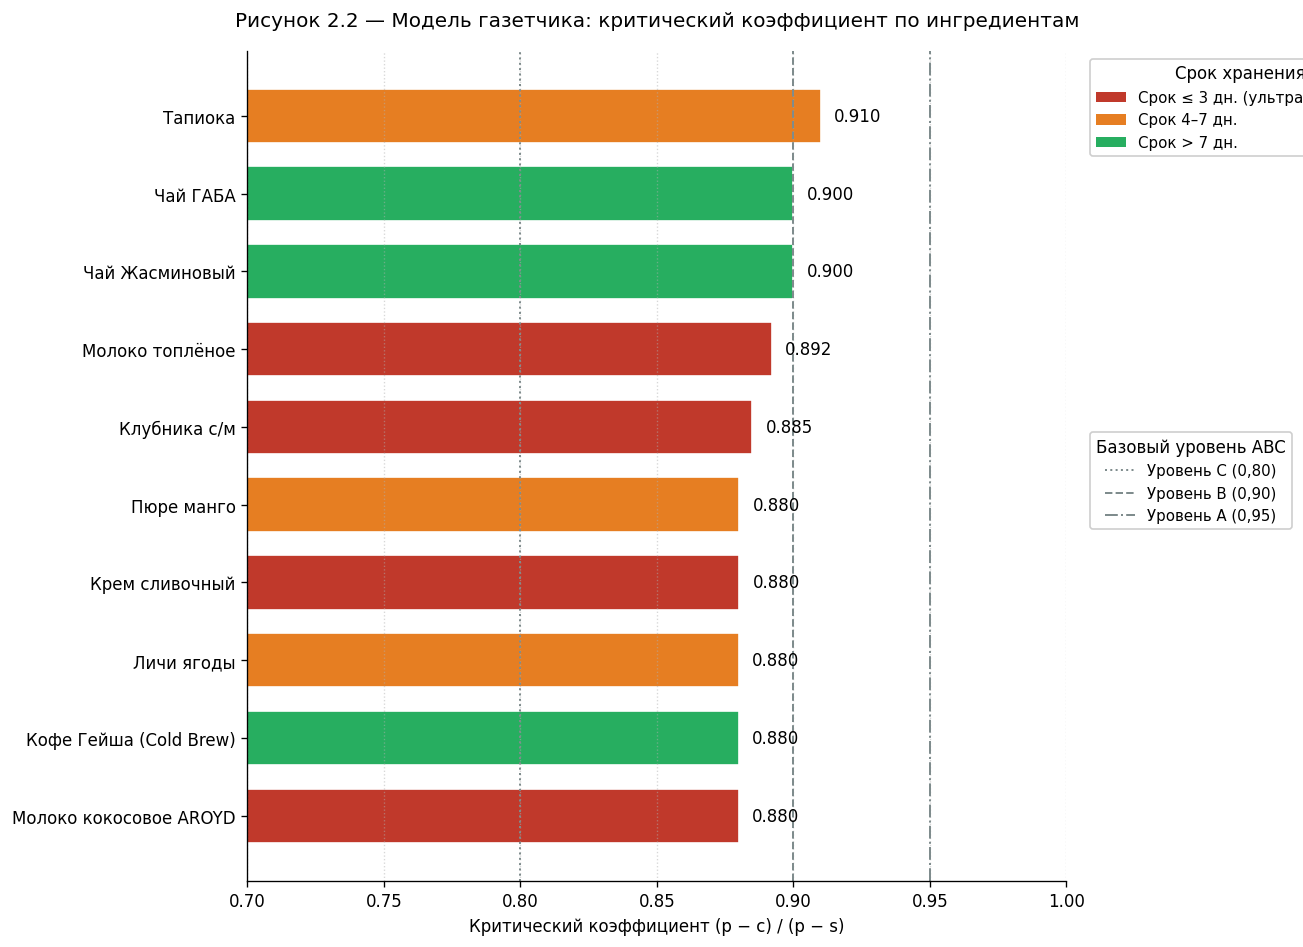


Диапазон critical ratio: 0.880 — 0.910
Среднее: 0.889
Медиана: 0.882


In [47]:
# ============================================================================
# 1. ИСХОДНЫЕ ДАННЫЕ
# ============================================================================
# Закупочная цена c — из накладных iiko (руб./ед.)
# Цена реализации p — рассчитывается как средняя выручка от напитка / норма
#                    расхода ингредиента по техкарте (руб./ед.)
# Срок хранения (shelf_open_days) после вскрытия — из справочника поставщика
# ----------------------------------------------------------------------------

ingredients = pd.DataFrame([
    # Скоропортящиеся, обычно AZ/BZ — высокая концентрация списаний
    {"product_id":  8, "name": "Молоко топлёное",       "c":  180, "p": 1667, "shelf_open_days": 3, "abc_xyz": "AZ"},
    {"product_id": 11, "name": "Крем сливочный",        "c":  320, "p": 2667, "shelf_open_days": 2, "abc_xyz": "AZ"},
    {"product_id":  9, "name": "Молоко кокосовое AROYD","c":  280, "p": 2333, "shelf_open_days": 3, "abc_xyz": "AY"},
    {"product_id": 21, "name": "Клубника с/м",          "c":  360, "p": 3125, "shelf_open_days": 3, "abc_xyz": "AZ"},
    {"product_id": 22, "name": "Личи ягоды",            "c":  420, "p": 3500, "shelf_open_days": 5, "abc_xyz": "BZ"},
    {"product_id": 19, "name": "Пюре манго",            "c":  290, "p": 2417, "shelf_open_days": 5, "abc_xyz": "BY"},

    # Чай и сухие основы, обычно AY/BY — длительный срок хранения,
    # критический коэффициент ближе к 0,95, т.к. цена утилизации низкая
    {"product_id":  2, "name": "Чай Жасминовый",        "c":  450, "p": 4500, "shelf_open_days": 21, "abc_xyz": "AY"},
    {"product_id":  3, "name": "Чай ГАБА",              "c":  680, "p": 6800, "shelf_open_days": 21, "abc_xyz": "AY"},
    {"product_id":  6, "name": "Кофе Гейша (Cold Brew)","c":  520, "p": 4333, "shelf_open_days": 14, "abc_xyz": "AZ"},
    {"product_id": 10, "name": "Тапиока",               "c":  450, "p": 5000, "shelf_open_days":  7, "abc_xyz": "AY"},
])


# ============================================================================
# 2. РАСЧЁТ КРИТИЧЕСКОГО КОЭФФИЦИЕНТА
# ============================================================================
def newsvendor_critical_ratio(p: float, c: float, s: float = 0.0) -> float:
    """
    Возвращает critical ratio (p - c) / (p - s).

    Для скоропортящихся ингредиентов ликвидационная стоимость s = 0
    (испорченный ингредиент утилизируется, средств не возвращает).
    """
    if p <= s:
        raise ValueError(f"Цена реализации p={p} должна быть больше ликвидационной s={s}")
    return (p - c) / (p - s)


def underage_cost(p: float, c: float) -> float:
    """Cu — цена дефицита (упущенная маржа на единицу)."""
    return p - c


def overage_cost(c: float, s: float = 0.0) -> float:
    """Co — цена избытка (убыток от списания единицы)."""
    return c - s


# Применяем функции к датафрейму
ingredients["c_under"] = ingredients.apply(lambda r: underage_cost(r["p"], r["c"]), axis=1)
ingredients["c_over"]  = ingredients.apply(lambda r: overage_cost(r["c"]), axis=1)
ingredients["critical_ratio"] = ingredients.apply(
    lambda r: newsvendor_critical_ratio(r["p"], r["c"]), axis=1
)


# ============================================================================
# 3. ИНТЕРПРЕТАЦИЯ: какой квантиль выбрать для страхового запаса
# ============================================================================
# Логика главы 3.4 ВКР:
#   - базовый квантиль определяется ABC-группой (A → 0.95, B → 0.90, C → 0.80)
#   - для скоропортящихся (shelf_open_days <= 3) — снижается на 5 п.п.
#   - сверху накладывается newsvendor cap = critical_ratio
# Итоговый квантиль = min(базовый_с_коррекцией, critical_ratio)
# ----------------------------------------------------------------------------
def base_quantile(abc_xyz: str) -> float:
    """Базовый квантиль по первой букве ABC-группы."""
    return {"A": 0.95, "B": 0.90, "C": 0.80}[abc_xyz[0]]


def adjusted_quantile(row) -> float:
    base = base_quantile(row["abc_xyz"])
    # Коррекция за короткий срок хранения
    if row["shelf_open_days"] <= 3:
        base -= 0.05
    # Newsvendor cap: нельзя ставить квантиль выше критического коэффициента
    return round(min(base, row["critical_ratio"]), 3)


ingredients["q_final"] = ingredients.apply(adjusted_quantile, axis=1)


# ============================================================================
# 4. ВЫВОД РЕЗУЛЬТАТОВ
# ============================================================================
print("\n=== Модель газетчика: критический коэффициент по ингредиентам ===\n")
result = ingredients[[
    "product_id", "name", "abc_xyz", "shelf_open_days",
    "c", "p", "c_under", "c_over", "critical_ratio", "q_final"
]].copy()
result.columns = [
    "ID", "Ингредиент", "ABC/XYZ", "Срок, дн.",
    "c, руб.", "p, руб.", "Cu (дефицит)", "Co (избыток)",
    "Critical ratio", "Итог. квантиль"
]
# Округлим
result["Critical ratio"] = result["Critical ratio"].round(3)
print(result.to_string(index=False))


# ============================================================================
# 5. ГРАФИК — Рисунок 2.2 ВКР
# ============================================================================
fig, ax = plt.subplots(figsize=(11, 8))

# Сортируем по critical_ratio для наглядности
plot_df = ingredients.sort_values("critical_ratio").reset_index(drop=True)

# Цвет столбца зависит от срока хранения
colors = ["#C0392B" if d <= 3 else "#E67E22" if d <= 7 else "#27AE60"
          for d in plot_df["shelf_open_days"]]

bars = ax.barh(plot_df["name"], plot_df["critical_ratio"],
               color=colors, edgecolor="white", height=0.7)

for bar, val in zip(bars, plot_df["critical_ratio"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)

# Опорные вертикальные линии для базовых уровней сервиса ABC
line_c = ax.axvline(0.80, color="#7F8C8D", linestyle=":",  linewidth=1.2)
line_b = ax.axvline(0.90, color="#7F8C8D", linestyle="--", linewidth=1.2)
line_a = ax.axvline(0.95, color="#7F8C8D", linestyle="-.", linewidth=1.2)

ax.set_xlim(0.70, 1.00)
ax.set_xlabel("Критический коэффициент (p − c) / (p − s)")
ax.set_title("Рисунок 2.2 — Модель газетчика: критический коэффициент по ингредиентам",
             fontsize=12, pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.5)

# Две легенды: верхняя — про сроки хранения (цвета),
# нижняя — про базовые уровни сервиса ABC (линии).
from matplotlib.patches import Patch
shelf_legend = [
    Patch(facecolor="#C0392B", label="Срок ≤ 3 дн. (ультракороткий)"),
    Patch(facecolor="#E67E22", label="Срок 4–7 дн."),
    Patch(facecolor="#27AE60", label="Срок > 7 дн."),
]
leg1 = ax.legend(handles=shelf_legend, loc="upper left",
                 bbox_to_anchor=(1.02, 1.0), fontsize=9,
                 title="Срок хранения", framealpha=0.95)
leg2 = ax.legend(handles=[line_c, line_b, line_a],
                 labels=["Уровень C (0,80)", "Уровень B (0,90)", "Уровень A (0,95)"],
                 loc="upper left", bbox_to_anchor=(1.02, 0.55), fontsize=9,
                 title="Базовый уровень ABC", framealpha=0.95)
ax.add_artist(leg1)

plt.tight_layout()
plt.savefig("fig_2_2_newsvendor.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nДиапазон critical ratio: "
      f"{ingredients['critical_ratio'].min():.3f} — "
      f"{ingredients['critical_ratio'].max():.3f}")
print(f"Среднее: {ingredients['critical_ratio'].mean():.3f}")
print(f"Медиана: {ingredients['critical_ratio'].median():.3f}")

In [48]:
service_levels_matrix = pd.DataFrame([
    {'ABC×XYZ': 'AX', 'Базовый квантиль': 0.95, 'Скоропортящ.': 0.95, 'newsvendor cap': 0.95, 'Итог': 0.95,
     'Обоснование': 'Высокий оборот, низкая вариабельность — макс. уровень сервиса'},
    {'ABC×XYZ': 'AY', 'Базовый квантиль': 0.95, 'Скоропортящ.': 0.90, 'newsvendor cap': 0.95, 'Итог': 0.90,
     'Обоснование': 'Высокий оборот, средняя вариабельность'},
    {'ABC×XYZ': 'AZ', 'Базовый квантиль': 0.95, 'Скоропортящ.': 0.90, 'newsvendor cap': 0.91, 'Итог': 0.90,
     'Обоснование': 'Высокий оборот, высокая вариабельность — ограничено newsvendor'},
    {'ABC×XYZ': 'BX', 'Базовый квантиль': 0.90, 'Скоропортящ.': 0.90, 'newsvendor cap': 0.90, 'Итог': 0.90,
     'Обоснование': 'Средний оборот, низкая вариабельность'},
    {'ABC×XYZ': 'BY', 'Базовый квантиль': 0.90, 'Скоропортящ.': 0.85, 'newsvendor cap': 0.90, 'Итог': 0.90,
     'Обоснование': 'Средний оборот, основная масса позиций PIMS'},
    {'ABC×XYZ': 'BZ', 'Базовый квантиль': 0.90, 'Скоропортящ.': 0.85, 'newsvendor cap': 0.91, 'Итог': 0.90,
     'Обоснование': 'Средний оборот, высокая вариабельность'},
    {'ABC×XYZ': 'CX', 'Базовый квантиль': 0.80, 'Скоропортящ.': 0.80, 'newsvendor cap': 0.80, 'Итог': 0.80,
     'Обоснование': 'Низкий оборот, низкая вариабельность'},
    {'ABC×XYZ': 'CY', 'Базовый квантиль': 0.80, 'Скоропортящ.': 0.80, 'newsvendor cap': 0.80, 'Итог': 0.80,
     'Обоснование': 'Низкий оборот, минимальный SS'},
    {'ABC×XYZ': 'CZ', 'Базовый квантиль': 0.80, 'Скоропортящ.': 0.80, 'newsvendor cap': 0.80, 'Итог': 0.80,
     'Обоснование': 'Низкий оборот, высокая вариабельность'},
])
print('Таблица 3.6б — Полная матрица уровней сервиса AX–CZ:')
print(service_levels_matrix.to_string(index=False))
service_levels_matrix.to_csv('/content/service_levels_matrix.csv', index=False, encoding='utf-8-sig')

Таблица 3.6б — Полная матрица уровней сервиса AX–CZ:
ABC×XYZ  Базовый квантиль  Скоропортящ.  newsvendor cap  Итог                                                    Обоснование
     AX             0.950         0.950           0.950 0.950  Высокий оборот, низкая вариабельность — макс. уровень сервиса
     AY             0.950         0.900           0.950 0.900                         Высокий оборот, средняя вариабельность
     AZ             0.950         0.900           0.910 0.900 Высокий оборот, высокая вариабельность — ограничено newsvendor
     BX             0.900         0.900           0.900 0.900                          Средний оборот, низкая вариабельность
     BY             0.900         0.850           0.900 0.900                    Средний оборот, основная масса позиций PIMS
     BZ             0.900         0.850           0.910 0.900                         Средний оборот, высокая вариабельность
     CX             0.800         0.800           0.800 0.800           

### 8.1 Расчёт страхового запаса: квантильный vs классический

Средний страховой запас по группам:
     ss_classic_mean  ss_quantile_mean  reduction_pct_mean   n
abc                                                           
A             26.300            16.600               8.700  15
B             19.300             7.700              20.700   8
C              0.200             0.400            -567.700   7


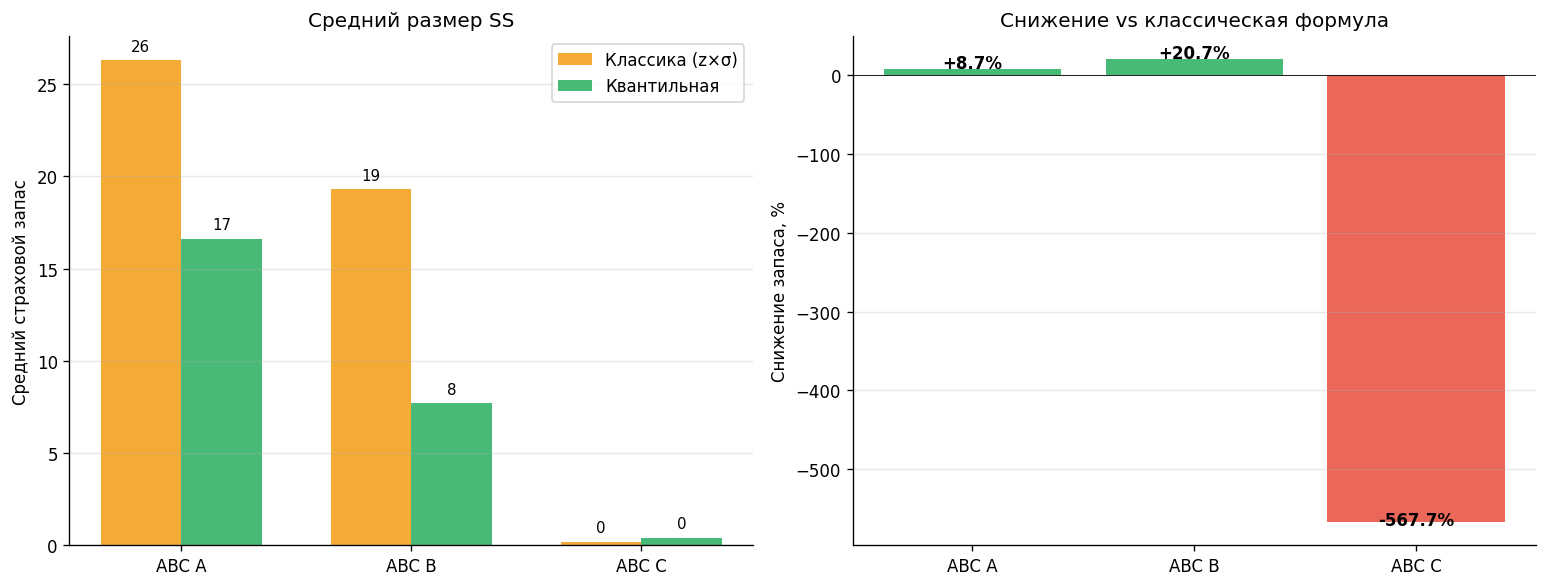

In [49]:
LEAD_TIME = 1

ss_rows = []
for pid, g in test_result.groupby('product_id'):
    g = g.sort_values('date')
    abc = abc_grp.get(pid, 'C')
    sd  = products.loc[products.product_id==pid, 'shelf_open_days'].values[0]
    q_col = {'A':'pred_q95','B':'pred_q90','C':'pred_q80'}[abc]
    if sd <= 3:
        q_col = {'pred_q95':'pred_q90','pred_q90':'pred_q80','pred_q80':'pred_q80'}[q_col]

    if q_col in g.columns:
        ss_quantile = (g[q_col] - g['pred_q50']).clip(lower=0).mean() * LEAD_TIME
    else:
        ss_quantile = np.nan

    z = {'A':1.65, 'B':1.28, 'C':0.84}[abc]
    sigma = g[TARGET_COL].std()
    ss_classic = z * sigma * np.sqrt(LEAD_TIME)

    reduction = (1 - ss_quantile/ss_classic) * 100 if ss_classic > 0 else 0

    ss_rows.append({
        'product_id':pid, 'abc':abc,
        'ss_classic':ss_classic, 'ss_quantile':ss_quantile,
        'reduction_pct':reduction
    })

ss_df = pd.DataFrame(ss_rows)
ss_summary = ss_df.groupby('abc').agg(
    ss_classic_mean=('ss_classic','mean'),
    ss_quantile_mean=('ss_quantile','mean'),
    reduction_pct_mean=('reduction_pct','mean'),
    n=('product_id','count')
).round(1)
print('Средний страховой запас по группам:')
print(ss_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
groups = ['A','B','C']
classic = [ss_summary.loc[g,'ss_classic_mean'] if g in ss_summary.index else 0 for g in groups]
quant   = [ss_summary.loc[g,'ss_quantile_mean'] if g in ss_summary.index else 0 for g in groups]
x = np.arange(3); w = 0.35
ax.bar(x-w/2, classic, w, label='Классика (z×σ)', color=COLOR_WARN, alpha=0.85)
ax.bar(x+w/2, quant,   w, label='Квантильная',     color=COLOR_OK, alpha=0.85)
for i, (c, q) in enumerate(zip(classic, quant)):
    ax.text(i-w/2, c+max(classic)*0.02, f'{c:.0f}', ha='center', fontsize=9)
    ax.text(i+w/2, q+max(classic)*0.02, f'{q:.0f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'ABC {g}' for g in groups])
ax.set_ylabel('Средний страховой запас')
ax.set_title('Средний размер SS'); ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
red = [ss_summary.loc[g,'reduction_pct_mean'] if g in ss_summary.index else 0 for g in groups]
colors_red = [COLOR_OK if r > 0 else COLOR_ACC for r in red]
bars = ax.bar([f'ABC {g}' for g in groups], red, color=colors_red, alpha=0.85)
for b, r in zip(bars, red):
    ax.text(b.get_x()+b.get_width()/2, r + (1 if r >= 0 else -3),
            f'{r:+.1f}%', ha='center', fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Снижение запаса, %')
ax.set_title('Снижение vs классическая формула')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig_9_safety_stock.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Итоговые таблицы для ВКР

In [50]:
print('='*80)
print('ИТОГОВЫЙ ОТЧЁТ ВКР — PIMS СППР (обновлённая версия)')
print('='*80)

print(f'\n[Раздел 1.3] Характеристики данных:')
print(f'  Длина истории:        {n_days} дней ({sales.date.min().date()} – {sales.date.max().date()})')
print(f'  Число ингредиентов:   {n_products}')
print(f'  CV: медиана {cv_median:.2f}, диапазон {cv_min:.2f}–{cv_max:.2f}')
print(f'  Доля дефицитных дней: {deficit_pct:.1f}%')
print(f'  Стоимость списаний:   {wo_per_year:,.0f} руб./год')

print(f'\n[Раздел 3.3] Качество прогноза (октябрь 2025):')
print(f'  WAPE avg_7d:           {wape(y_true, test_result["pred_baseline"]):.1f}%')
print(f'  WAPE seasonal naive:   {wape(y_true, test_result["pred_sn7"]):.1f}%')
print(f'  WAPE LightGBM q50:     {w_q50:.1f}%')
print(f'  Целевой порог:         25%')
print(f'  Бэктест 5 фолдов:      {bt_df["WAPE (%)"].mean():.1f}% ± {bt_df["WAPE (%)"].std():.1f}%')

print(f'\n[Раздел 3.3.5] Калибровка квантилей:')
for r in calib_rows:
    print(f'  {r["Квантиль"]}: ожидаем {r["Ожидаемое покрытие, %"]}%, факт {r["Фактическое покрытие, %"]}% — {r["Калибровка"]}')

print(f'\n[Раздел 3.4] Снижение страхового запаса (квантильный vs классический):')
for grp in ['A','B','C']:
    if grp in ss_summary.index:
        r = ss_summary.loc[grp, 'reduction_pct_mean']
        print(f'  Группа {grp}: {r:+.1f}%')


ИТОГОВЫЙ ОТЧЁТ ВКР — PIMS СППР (обновлённая версия)

[Раздел 1.3] Характеристики данных:
  Длина истории:        670 дней (2024-01-01 – 2025-10-31)
  Число ингредиентов:   30
  CV: медиана 0.47, диапазон 0.39–0.56
  Доля дефицитных дней: 7.3%
  Стоимость списаний:   170,400 руб./год

[Раздел 3.3] Качество прогноза (октябрь 2025):
  WAPE avg_7d:           17.7%
  WAPE seasonal naive:   19.2%
  WAPE LightGBM q50:     12.8%
  Целевой порог:         25%
  Бэктест 5 фолдов:      13.4% ± 0.9%

[Раздел 3.3.5] Калибровка квантилей:
  q80: ожидаем 80%, факт 82.8% — OK
  q90: ожидаем 90%, факт 87.9% — OK
  q95: ожидаем 95%, факт 94.3% — OK

[Раздел 3.4] Снижение страхового запаса (квантильный vs классический):
  Группа A: +8.7%
  Группа B: +20.7%
  Группа C: -567.7%


In [51]:
# Экспорт всех таблиц для приложений ВКР
test_result.to_csv('/content/test_result.csv', index=False, encoding='utf-8-sig')
metrics_df.to_csv('/content/metrics_table_3_3.csv', index=False, encoding='utf-8-sig')
table_35.to_csv('/content/feature_importance_table_3_5.csv', index=False, encoding='utf-8-sig')
ss_summary.to_csv('/content/safety_stock_comparison.csv', encoding='utf-8-sig')
prod_full.to_csv('/content/abc_xyz_table.csv', index=False, encoding='utf-8-sig')
bt_df.to_csv('/content/backtest.csv', index=False, encoding='utf-8-sig')
calib_df.to_csv('/content/quantile_calibration.csv', index=False, encoding='utf-8-sig')
robust_df.to_csv('/content/wape_robustness.csv', index=False, encoding='utf-8-sig')
weather_exp.to_csv('/content/weather_experiment.csv', index=False, encoding='utf-8-sig')
service_levels_matrix.to_csv('/content/service_levels_matrix.csv', index=False, encoding='utf-8-sig')
print('Все таблицы экспортированы в /content/:')
print('  - metrics_table_3_3.csv          — качество прогноза')
print('  - backtest.csv                   — бэктест по 5 фолдам')
print('  - quantile_calibration.csv       — калибровка квантилей')
print('  - wape_robustness.csv            — чувствительность WAPE')
print('  - weather_experiment.csv         — эксперимент с погодой')
print('  - service_levels_matrix.csv      — единое правило AX–CZ')


Все таблицы экспортированы в /content/:
  - metrics_table_3_3.csv          — качество прогноза
  - backtest.csv                   — бэктест по 5 фолдам
  - quantile_calibration.csv       — калибровка квантилей
  - wape_robustness.csv            — чувствительность WAPE
  - weather_experiment.csv         — эксперимент с погодой
  - service_levels_matrix.csv      — единое правило AX–CZ
